Name: Milou van Megen. Date: 03/09/2026

## 1. Mathematical Formulation

Local Regression (LOESS) estimates the expected target value $\hat{y}_0$ at an evaluation point $x_0$ using $k$-nearest neighbors.

1. **Distance Calculation**: Compute Euclidean distances to all observed points:
   $$d_i = |x_i - x_0|$$

2. **$k$-NN Selection**: Identify the subset $N_k(x_0)$ containing the $k$ closest neighbors to $x_0$, and determine maximum neighborhood distance:
   $$\Delta(x_0) = \max_{i \in N_k(x_0)} d_i$$

3. **Linear Distance Weighting**: Assign linearly decaying weights $w_i(x_0)$ to each neighbor based on its relative distance:
   $$w_i(x_0) = 1 - \frac{d_i}{\Delta(x_0)}, \quad \text{for } i \in N_k(x_0)$$

4. **Prediction**: Evaluate the fitted linear function at 
   $x_0$:$$\hat{y}(x_0) = \hat{\beta}_0 + \hat{\beta}_1 x_0$$

5. **Local Standard Error**: Compute the unweighted root mean square error (RMSE) of the local fit on the nearest neighbors:
   $$SE(x_0) = \sqrt{\frac{1}{k} \sum_{i \in N_k(x_0)} \left( y_i - \hat{y_i} \right)^2}$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression

In [2]:
# Import mortality data from csv
data = pd.read_csv('pollution_cleaneddata.csv')

In [3]:
def local_regression(x, y, x0, k, show=False):
    """
    Perform simple local regression (LOESS) on the given data.

    Parameters:
    x (array-like): A vector of the response variable data.
    y (array-like): A vector of the predictor variable data.
    x0 (array-like): A vector containing the points at which to evaluate the local regression.
    k (int): The number of nearest neighbors to consider for the local regression.
    show (bool): If True, display a scatter plot of the data and the predicted points.

    Returns:
    pred (array-like): A vector containing the estimated values of y at x0 using local regression.
    se (array-like): A vector containing the standard errors of the estimates at x0.
    """

    # Convert inputs to 1D numpy arrays for consistent indexing and math
    x = np.asarray(x)
    y = np.asarray(y)
    x0 = np.asarray(x0)

    # Initialize output arrays
    y_pred_all = np.zeros(len(x0))
    se_all = np.zeros(len(x0))
    if show: # Initialize slope array for tangent lines (optional)
        slope_all = np.zeros(len(x0)) 

    # Initialize instance of the linear regression model
    model = LinearRegression()

    for idx, x0_i in enumerate(x0):
        # 1. Calculate absolute distances to all training points
        distances = np.abs(x - x0_i)

        # 2. Select indices of the k-nearest neighbors
        nearest_indices = np.argsort(distances)[:k]

        # 3. Extract nearest neighbor points
        x_nearest = x[nearest_indices].reshape(-1, 1)  # Shape (k, 1) for scikit
        y_nearest = y[nearest_indices] 
        dist_nearest = distances[nearest_indices]

        # 4. Compute distance weights
        max_dist = np.max(dist_nearest)
        weights_dist = 1 - (dist_nearest / max_dist)

        # 5. Fit local linear regression model with distance weights
        model.fit(x_nearest, y_nearest, sample_weight=weights_dist)

        # 6. Predict y for x0_i
        y_pred_all[idx] = model.predict(np.array([[x0_i]])).item()

        # 7. Compute standard error (SE) for the local regression
        y_fit = model.predict(x_nearest)
        residuals = y_nearest - y_fit
        mse = np.average(residuals ** 2)
        se_all[idx] = np.sqrt(mse)
        if show:
            slope_all[idx] = model.coef_[0]  # Store slope for each x0_i for plotting tangent lines

    # Optional plotting
    if show:
        plt.figure(figsize=(10, 6))

        # Plot raw data and predictions
        plt.scatter(x, y, color='tab:blue', alpha=0.4, label='Data points')
        plt.errorbar(x0, y_pred_all, yerr=se_all, fmt='o', color='orangered', 
                     ecolor='salmon', elinewidth=1.5, capsize=3, label='Local prediction ± SE')

        # To draw a short tangent line segments showing the slope at each x0, 
        # determine the tangent segment width based on x range
        delta = (np.max(x) - np.min(x)) * 0.015

        # Start for loop to plot tangent lines at each x0_i
        for i in range(len(x0)):
            x_tan = np.array([x0[i] - delta, x0[i] + delta])
            y_tan = y_pred_all[i] + slope_all[i] * (x_tan - x0[i])  # Point-slope line

            # Label only the first line segment so the legend isn't cluttered
            label_text = 'Tangent lines' if i == 0 else ""
            plt.plot(x_tan, y_tan, color='black', linewidth=1, label=label_text)

        plt.xlabel('Low income households [%]')
        plt.ylabel('Mortality rate [n per 100,000]')
        plt.title(f'Weighted local regression predictions of mortality (k={k})')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    return y_pred_all, se_all

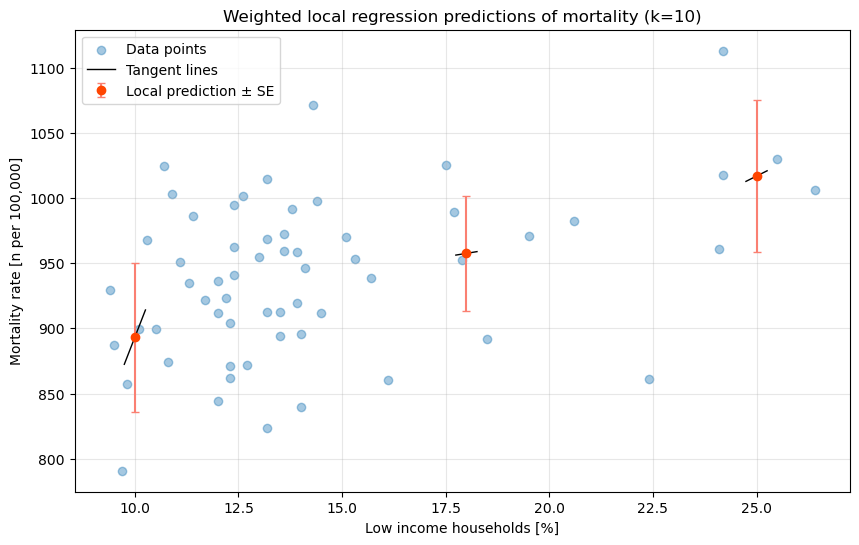

Standard Error: [57.099713   44.21753005 58.09754203]
Estimated y values for pollution data: [ 893.28088224  957.59668824 1016.91718426]


In [4]:
# MAIN CODE: this block calls the function local_regression() using the imported mortality data.

eval_points = [10, 18, 25]
pollution_y, pollution_se = local_regression(data['POOR'], data['MORT'], eval_points, 10, show=True)
print("Standard Error:", pollution_se)
print("Estimated y values for pollution data:", pollution_y)

k=2: Estimated y values: [ 899.264  952.529 1030.38 ], Standard errors: [29.44534058 25.97627471 58.53147092]
k=3: Estimated y values: [ 885.38333333  934.161      1030.38      ], Standard errors: [23.54299683 28.51359774 48.35584234]
k=4: Estimated y values: [ 885.38333333  934.161      1043.84326923], Standard errors: [33.43912941 24.69476043 63.30051736]
k=5: Estimated y values: [ 885.12530986  950.58250582 1033.30692946], Standard errors: [58.14281689 96.9121971  50.18474013]
k=6: Estimated y values: [ 885.12530986  964.62635707 1026.76904956], Standard errors: [69.27774681 97.09797779 86.65431511]
k=7: Estimated y values: [ 884.47270416  960.21133554 1020.68964727], Standard errors: [68.71004975 60.67698959 65.86194834]
k=8: Estimated y values: [ 888.4351327   958.14678879 1018.89195147], Standard errors: [56.65539447 50.51815651 64.63555359]
k=9: Estimated y values: [ 892.94441498  957.95775682 1017.28753552], Standard errors: [61.05867503 46.50222396 59.08949698]
k=10: Estimated

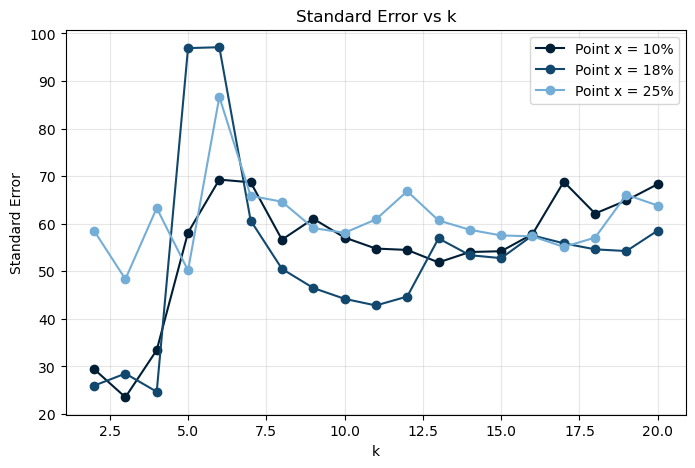

In [5]:
# More main code to plot the standard errors for different k values

se_matrix = np.array([]).reshape(0, len(eval_points))  # Initialize an empty array with shape (0, 3)

# Fill the matrix using a for loop to iterate through k values from 2 to 20
for k in range(2, 21):
    y_pred, se = local_regression(data['POOR'], data['MORT'], eval_points, k, show=False) 
    print(f"k={k}: Estimated y values: {y_pred}, Standard errors: {se}") # Print predicted values and errors for all k
    se_matrix = np.vstack([se_matrix, se])  # Append the new SEs as a new row in the matrix

# Set some colors and labels for the different evaluated points
colors = ["#001f36", "#12486E", "#74aed7"]
labels = [f'Point x = {x}%' for x in eval_points]

# Plot everything nicely
plt.figure(figsize=(8, 5))
for i in range(len(eval_points)):
    plt.plot(
        range(2, 21), 
        se_matrix[:, i], 
        marker='o', 
        color=colors[i], 
        label=labels[i]
    )
plt.xlabel('k')
plt.ylabel('Standard Error')
plt.title('Standard Error vs k')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


### Discussion of FAIR Principles

Overall, the code, data, and repository adhere well to the FAIR principles, with a few areas of improvement.

* **Findable:** The notebook, dataset, and configuration files are posted in a public GitHub repository with a descriptive README.md and standard project structure. Findability could be further enhanced by linking the repository to a published article, or creating a DOI by archiving the release on a platform like Zenodo. For the purpose of this exercise, however, there is little need to actually do so. 

* **Accessible:** The repository and data are freely accessible to anyone as they are part of a public repository on GitHub. Access does not require a license, password or any other form of authority.

* **Interoperable:** The project utilizes standard file formats (.ipynb for code, .csv for data, and .yml for configuration) that can be easily used across different operating systems and programming languages.

* **Reusable:** The repository is well-structured for others to adapt and build upon:
  * **Open License:** Including an MIT License provides clear rules on how the code can be shared, modified, and reused.
  * **Dependency Management:** The environment.yml file ensures the exact package setup can be recreated, keeping the code from breaking due to future library updates.
  * **Data Origin:** Citing the McDonald & Schwing (1973) paper gives full information on where the dataset comes from and how it was collected.